# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tensorflow.keras.models import save_model
from sklearn.utils.class_weight import compute_class_weight

2025-08-16 13:04:48.937681: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755349489.284017      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755349489.387559      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Preparing Data

In [2]:
train_generator = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_generator = ImageDataGenerator(rescale=1./255, validation_split=0.2)

test_generator = ImageDataGenerator(rescale=1./255)

In [3]:
train_ds = train_generator.flow_from_directory(
    directory = '../input/fer2013/train',
    target_size = (224, 224),
    class_mode = 'categorical',
    subset = 'training',
    batch_size = 64
)

Found 22968 images belonging to 7 classes.


In [4]:
val_ds = val_generator.flow_from_directory(
    directory = '../input/fer2013/train',
    target_size = (224, 224),
    class_mode = 'categorical',
    subset = 'validation',
    batch_size = 64
)

Found 5741 images belonging to 7 classes.


In [5]:
test_ds = test_generator.flow_from_directory(
    directory = '../input/fer2013/test',
    target_size = (224, 224),
    class_mode = 'categorical',
    batch_size = 64
)

Found 7178 images belonging to 7 classes.


# Data Visualization

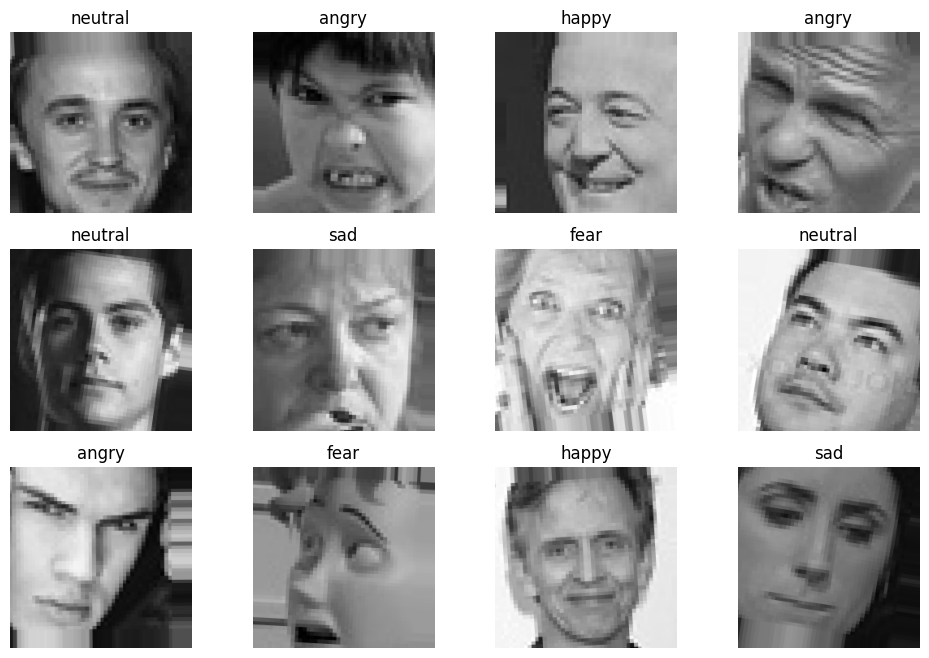

In [6]:
images, labels = next(train_ds)  
class_names = list(train_ds.class_indices.keys())

plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.show()

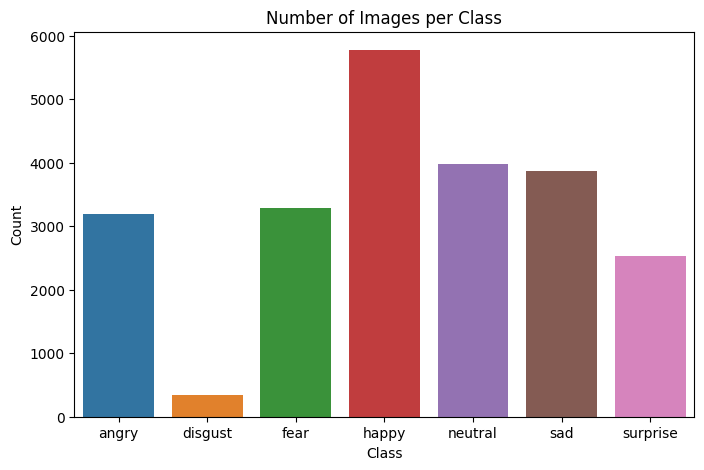

In [7]:
labels_all = [os.path.basename(os.path.dirname(path)) for path in train_ds.filepaths]
counts = dict(Counter(labels_all))

df_counts = pd.DataFrame(list(counts.items()), columns=['Class', 'Count'])
plt.figure(figsize=(8,5))
sns.barplot(x='Class', y='Count', data=df_counts)
plt.title('Number of Images per Class')
plt.show()

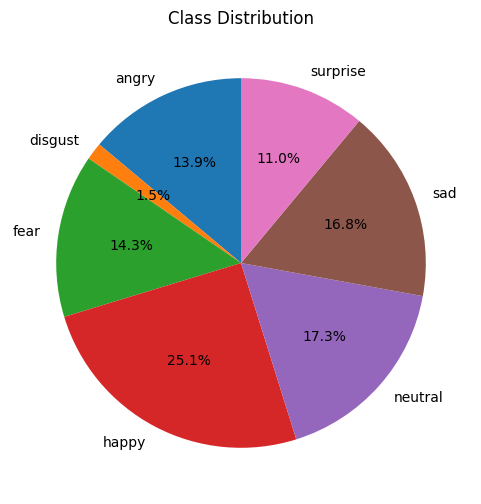

In [8]:
plt.figure(figsize=(6,6))
plt.pie(df_counts['Count'], labels=df_counts['Class'], autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution')
plt.show()

# Model Building & Training

In [9]:
base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
)

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(7, activation='softmax')
])

model.summary()

I0000 00:00:1755349531.924581      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1755349531.925231      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,661,095 (78.82 MB)

 Trainable params: 20,507,223 (78.23 MB)

 Non-trainable params: 153,872 (601.06 KB)

In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

y_train_labels = train_ds.classes  

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(7),
    y=y_train_labels
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: 1.0266404434114071, 1: 9.401555464592715, 2: 1.0009587727708533, 3: 0.5684585684585685, 4: 0.826068191627104, 5: 0.8491570541259982, 6: 1.2933160650937552}


In [12]:
history = model.fit (
    train_ds, validation_data=val_ds, epochs=50, callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1755349652.369751     124 service.cc:148] XLA service 0x7afafc004290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755349652.371472     124 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1755349652.371496     124 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1755349663.043503     124 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1755349684.514183     124 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755349684.670169     124 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755349685.247548     124 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

 76/359 ━━━━━━━━━━━━━━━━━━━━ 5:18 1s/step - accuracy: 0.2516 - loss: 1.8233

E0000 00:00:1755349835.634569     126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755349835.787877     126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755349836.321219     126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755349836.480875     126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755349837.245175     126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

359/359 ━━━━━━━━━━━━━━━━━━━━ 716s 1s/step - accuracy: 0.3694 - loss: 1.6076 - val_accuracy: 0.2284 - val_loss: 1.8367 - learning_rate: 0.0010
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 302s 840ms/step - accuracy: 0.5159 - loss: 1.2928 - val_accuracy: 0.3623 - val_loss: 1.7265 - learning_rate: 0.0010
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 302s 840ms/step - accuracy: 0.5703 - loss: 1.1308 - val_accuracy: 0.5607 - val_loss: 1.1527 - learning_rate: 0.0010
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 306s 851ms/step - accuracy: 0.5920 - loss: 1.0761 - val_accuracy: 0.5847 - val_loss: 1.1039 - learning_rate: 0.0010
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 300s 835ms/step - accuracy: 0.6167 - loss: 1.0080 - val_accuracy: 0.5680 - val_loss: 1.1359 - learning_rate: 0.0010
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 303s 842ms/step - accuracy: 0.6084 - loss: 1.0277 - val_accuracy: 0.6255 - val_loss: 1.0063 - learning_rate: 0.0010
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 302s 839ms/step - accuracy: 0.6302 - l

# Model Evaluation

In [13]:
loss, accuracy = model.evaluate(test_ds)
print("Test Accuracy:", accuracy)
print("Loss:", loss)

113/113 ━━━━━━━━━━━━━━━━━━━━ 71s 624ms/step - accuracy: 0.6677 - loss: 0.8749
Test Accuracy: 0.6752577424049377
Loss: 0.8778616189956665


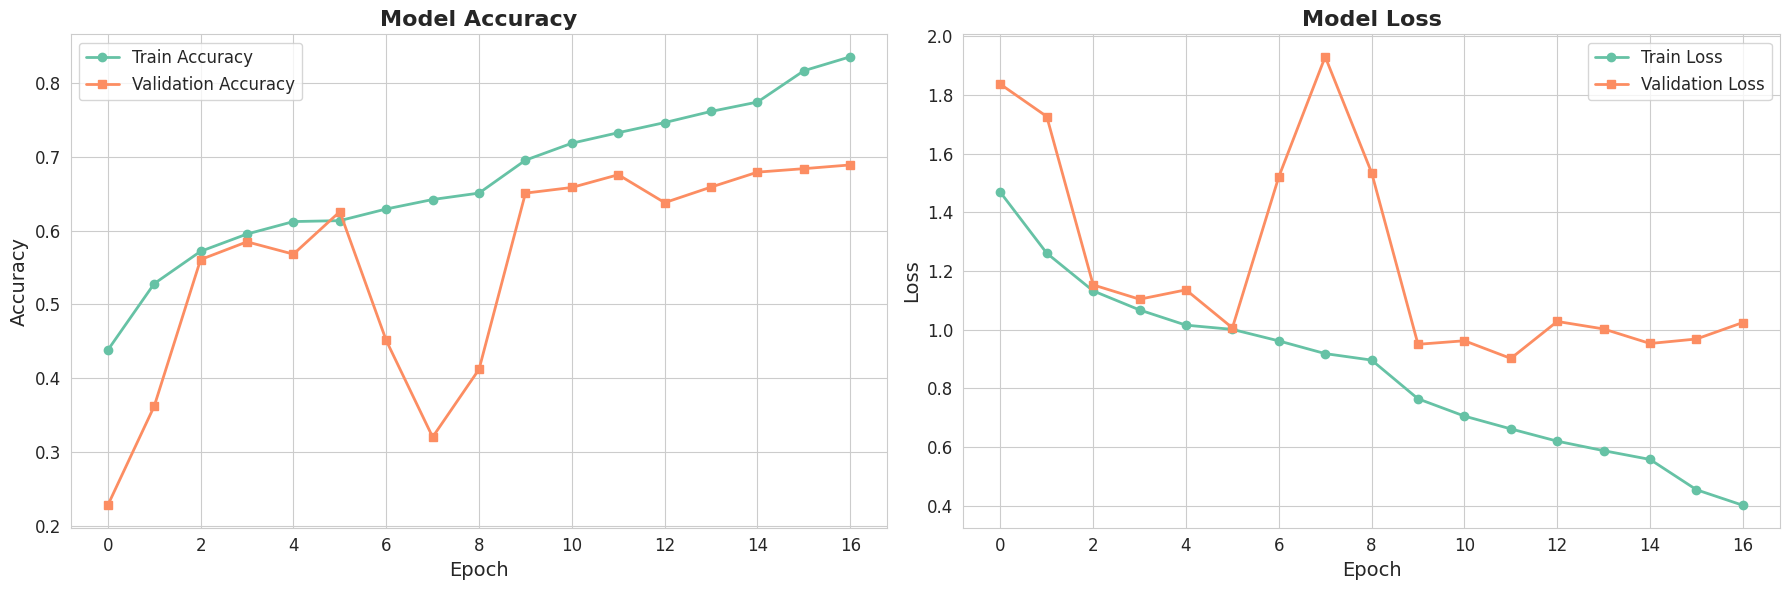

In [14]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

axs[0].plot(history.history['accuracy'], marker='o', linewidth=2, label='Train Accuracy')
axs[0].plot(history.history['val_accuracy'], marker='s', linewidth=2, label='Validation Accuracy')
axs[0].set_title('Model Accuracy', fontsize=16, fontweight='bold')
axs[0].set_xlabel('Epoch', fontsize=14)
axs[0].set_ylabel('Accuracy', fontsize=14)
axs[0].legend(fontsize=12)
axs[0].tick_params(axis='both', which='major', labelsize=12)

axs[1].plot(history.history['loss'], marker='o', linewidth=2, label='Train Loss')
axs[1].plot(history.history['val_loss'], marker='s', linewidth=2, label='Validation Loss')
axs[1].set_title('Model Loss', fontsize=16, fontweight='bold')
axs[1].set_xlabel('Epoch', fontsize=14)
axs[1].set_ylabel('Loss', fontsize=14)
axs[1].legend(fontsize=12)
axs[1].tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

In [15]:
y_true = []
y_pred = []

for X_batch, y_batch in test_ds:
    preds = model.predict(X_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch, axis=1))
    if len(y_true) >= test_ds.samples:
        break

print(classification_report(y_true, y_pred, target_names=list(test_ds.class_indices.keys())))

              precision    recall  f1-score   support

       angry       0.62      0.56      0.59       958
     disgust       0.48      0.72      0.58       111
        fear       0.52      0.49      0.50      1024
       happy       0.90      0.87      0.88      1774
     neutral       0.60      0.72      0.66      1233
         sad       0.57      0.51      0.54      1247
    surprise       0.76      0.80      0.78       831

    accuracy                           0.68      7178
   macro avg       0.64      0.67      0.65      7178
weighted avg       0.68      0.68      0.67      7178



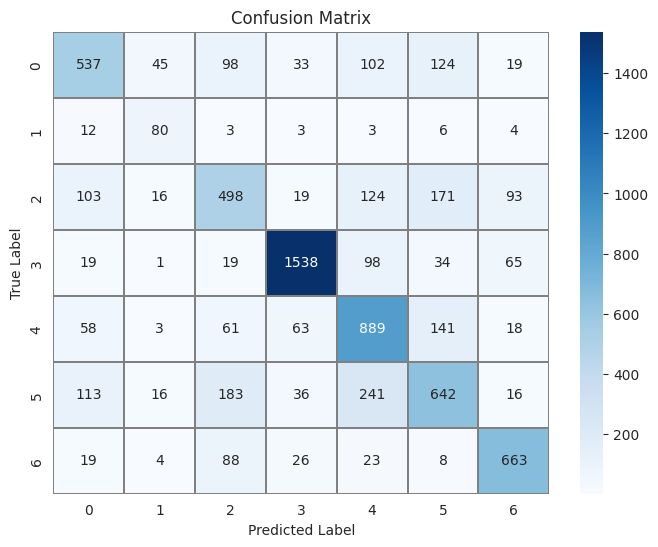

In [16]:
confusion_mtx = confusion_matrix(y_true, y_pred)
f, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.01, cmap="Blues", linecolor="gray", fmt='.0f', ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Save Model

In [17]:
model.save('/kaggle/working/model.h5')